In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# # read in the cleaned CSV with data from central valley stations
# path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
# if os.path.exists(path):
#     CV_rows = pd.read_csv(path, low_memory = False)
# else:
#     path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
#     CV_rows = pd.read_csv(path, low_memory = False)

# print(CV_rows)

# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_station_rows_nonna.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_station_rows_nonna.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

          STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0        USW00093193   36.7800  -119.7194  1941-12-04 00:00:00         SAO   
1        USW00093193   36.7800  -119.7194  1941-12-04 01:00:00         SAO   
2        USW00093193   36.7800  -119.7194  1941-12-04 02:00:00         SAO   
3        USW00093193   36.7800  -119.7194  1941-12-04 03:00:00         SAO   
4        USW00093193   36.7800  -119.7194  1941-12-04 04:00:00         SAO   
...              ...       ...        ...                  ...         ...   
8221089  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
8221090  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
8221091  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
8221092  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
8221093  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

         HourlyDewPointTemperature  HourlyDryBulbTemperature  \

In [3]:
#Remove duplicate hours for each station
CV_rows = CV_rows.drop_duplicates(subset=['STATION', 'year', 'month', 'day', 'hour'])

print(CV_rows.shape)

(7251147, 18)


In [4]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[CV_rows['month'].isin([11, 12, 1, 2, 3])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (3035802, 18)


In [5]:
# # Fill NaN HourlyVisibility values with the previous valid measurement (forward fill)
# CV_rows["HourlyVisibility"] = CV_rows["HourlyVisibility"].ffill()

# print(CV_rows["HourlyVisibility"].isna().sum())

In [6]:
# Find the earliest year with recorded data for each station
earliest_year_by_station = CV_rows.groupby("STATION")["year"].min().reset_index()
earliest_year_by_station.columns = ["STATION", "earliest_year"]
earliest_year_by_station = earliest_year_by_station.sort_values("earliest_year")

print("Earliest year with recorded data for each station:")
print(earliest_year_by_station)

Earliest year with recorded data for each station:
                       STATION  earliest_year
0               BAKERSFIELD AP           1928
9        SACRAMENTO MATHER AFB           1930
8           SACRAMENTO AP ASOS           1931
6            RED BLUFF MUNI AP           1939
10    SACRAMENTO MCCLELLAN AFB           1939
12                 STOCKTON AP           1941
3         FRESNO YOSEMITE INTL           1941
2                   CASTLE AFB           1942
13            TRAVIS FIELD AFB           1943
7                   REDDING AP           1944
1                    BEALE AFB           1959
4           LEMOORE REEVES NAS           1961
11  SACRAMENTO METROPOLITAN AP           1972
5       LIVERMORE MUNICIPAL AP           1999


In [7]:
# Remove the earliest year for each station
CV_rows = CV_rows.merge(
    earliest_year_by_station,
    left_on="STATION",
    right_on="STATION",
    how="left"
)

CV_rows = CV_rows[CV_rows["year"] != CV_rows["earliest_year"]].drop(columns="earliest_year")

print("CV_rows after removing earliest year for each station:", CV_rows.shape)

CV_rows after removing earliest year for each station: (3016897, 18)


In [8]:
CV_rows['HourlyDewpointDepression'] = (
    CV_rows['HourlyDryBulbTemperature'] - CV_rows['HourlyDewPointTemperature']
)

CV_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
671,3.0,3.0,0.0
672,3.0,3.0,0.0
673,3.5,2.4,1.1
674,3.5,3.5,0.0
675,3.5,3.5,0.0


In [9]:
# Ensure wind direction is numeric; "000" is treated as calm (0, 0)
wd1 = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")

# Unit-vector style components from wind direction
# 360 = north, 180 = south, 270 = west, 90 = east
# Determine the north-south component of the wind direction
CV_rows["wind_ns_component"] = np.where(
    wd1.eq(0) | wd1.isna(),
    0.0,
    np.cos(np.deg2rad(wd1))
)

# Determine west-east component of the wind direction
CV_rows["wind_we_component"] = np.where(
    wd1.eq(0) | wd1.isna(),
    0.0,
    np.sin(np.deg2rad(wd1))
)

CV_rows[["HourlyWindDirection", "wind_ns_component", "wind_we_component"]].head()

,HourlyWindDirection,wind_ns_component,wind_we_component
671,45.0,0.707107,0.707107
672,45.0,0.707107,0.707107
673,0.0,0.000000,0.000000
674,315.0,0.707107,-0.707107
675,315.0,0.707107,-0.707107


In [10]:
# Classify each observation as up-valley or down-valley relative to valley angle = 330°
valley_angle = 330.0  # interpreted as the up-valley flow direction (toward 330°)

wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")  # meteorological "from" direction
ws = pd.to_numeric(CV_rows["HourlyWindSpeed"], errors="coerce")

# Convert to "to" direction (direction wind is blowing toward)
wd_to = (wd + 180.0) % 360.0

# Signed alignment with valley axis (+ up-valley, - down-valley)
# cos(delta) > 0 means aligned with up-valley axis, < 0 means opposite (down-valley)
delta = np.deg2rad(wd_to - valley_angle)
valley_alignment = np.cos(delta)

# Optional speed-weighted along-valley component
CV_rows["valley_along_component"] = valley_alignment * ws

calm_mask = wd.eq(0) | ws.eq(0)  # "000" direction and/or zero speed => calm
missing_mask = wd.isna() | ws.isna()

# Classify each observation as "up_valley", "down_valley", "cross_valley", "calm", or "missing"
CV_rows["valley_wind_type"] = np.select(
    [
        missing_mask,
        calm_mask,
        valley_alignment > 0,
        valley_alignment < 0,
    ],
    [
        "missing",
        "calm",
        "up_valley",
        "down_valley",
    ],
    default="cross_valley",
)

# Quick station-level check of the counts of each valley wind type
station_valley_counts = (
    CV_rows.groupby(["STATION", "valley_wind_type"])
    .size()
    .unstack(fill_value=0)
)

station_valley_counts.head()

valley_wind_type,calm,down_valley,up_valley
STATION,,,
BAKERSFIELD AP,68202,135043,114091
BEALE AFB,42874,57074,83374
CASTLE AFB,68010,60022,57934
FRESNO YOSEMITE INTL,59096,95939,117079
LEMOORE REEVES NAS,39263,86689,62948


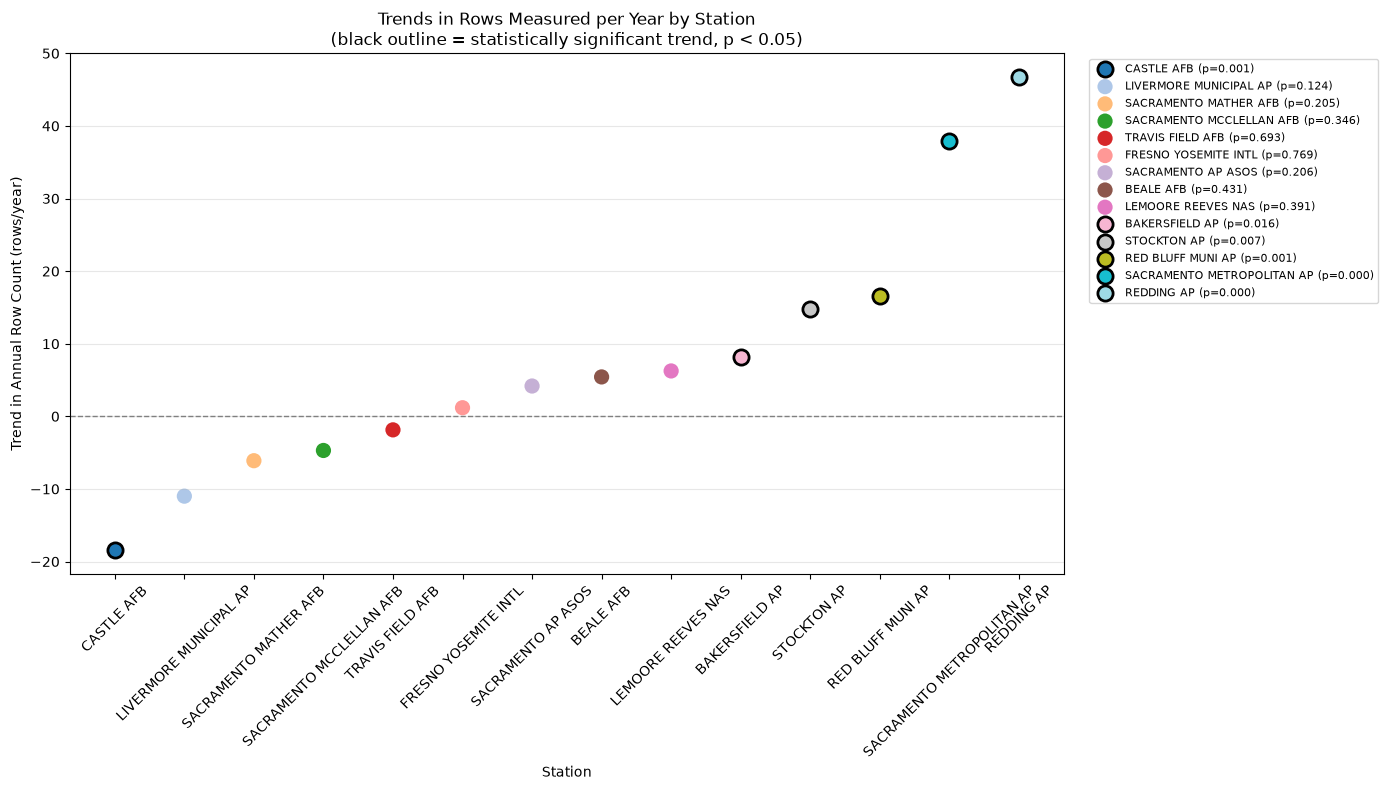

,STATION,slope_rows_per_year,p_value,n_years,significant
2,CASTLE AFB,-18.472678,1.307804e-03,66,True
5,LIVERMORE MUNICIPAL AP,-10.992063,1.237922e-01,27,False
9,SACRAMENTO MATHER AFB,-6.108522,2.054307e-01,77,False
10,SACRAMENTO MCCLELLAN AFB,-4.699459,3.461760e-01,72,False
13,TRAVIS FIELD AFB,-1.860253,6.925147e-01,77,False
3,FRESNO YOSEMITE INTL,1.188141,7.685129e-01,82,False
8,SACRAMENTO AP ASOS,4.178877,2.057642e-01,95,False
1,BEALE AFB,5.430709,4.311273e-01,61,False
4,LEMOORE REEVES NAS,6.253628,3.909340e-01,65,False
0,BAKERSFIELD AP,8.218516,1.550540e-02,98,True


In [11]:
# Yearly row counts and station-level trends

yearly_row_counts = (
    CV_rows.groupby(["STATION", "year"])
    .size()
    .reset_index(name="row_count")
)

trend_records = []

for station, station_data in yearly_row_counts.groupby("STATION"):
    station_data = station_data.sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].to_numpy()
    y = station_data["row_count"].to_numpy()

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    trend_records.append({
        "STATION": station,
        "slope_rows_per_year": slope,
        "p_value": p_value,
        "n_years": len(station_data),
        "significant": p_value < 0.05,
    })

trend_summary_rows = pd.DataFrame(trend_records).sort_values("slope_rows_per_year")

# Plot one trend datapoint per station
# Make sure station names do not overlap in the ticks on the x-axis
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(trend_summary_rows)))

for color, (_, row) in zip(colors, trend_summary_rows.iterrows()):
    ax.scatter(
        row["STATION"],
        row["slope_rows_per_year"],
        s=120,
        color=color,
        edgecolors="black" if row["significant"] else "none",
        linewidths=2 if row["significant"] else 0,
        label=(
            f'{row["STATION"]} '
            f'(p={row["p_value"]:.3f})'
        ),
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Station")
ax.set_ylabel("Trend in Annual Row Count (rows/year)")
ax.set_title(
    "Trends in Rows Measured per Year by Station\n"
    "(black outline = statistically significant trend, p < 0.05)"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

display(trend_summary_rows)

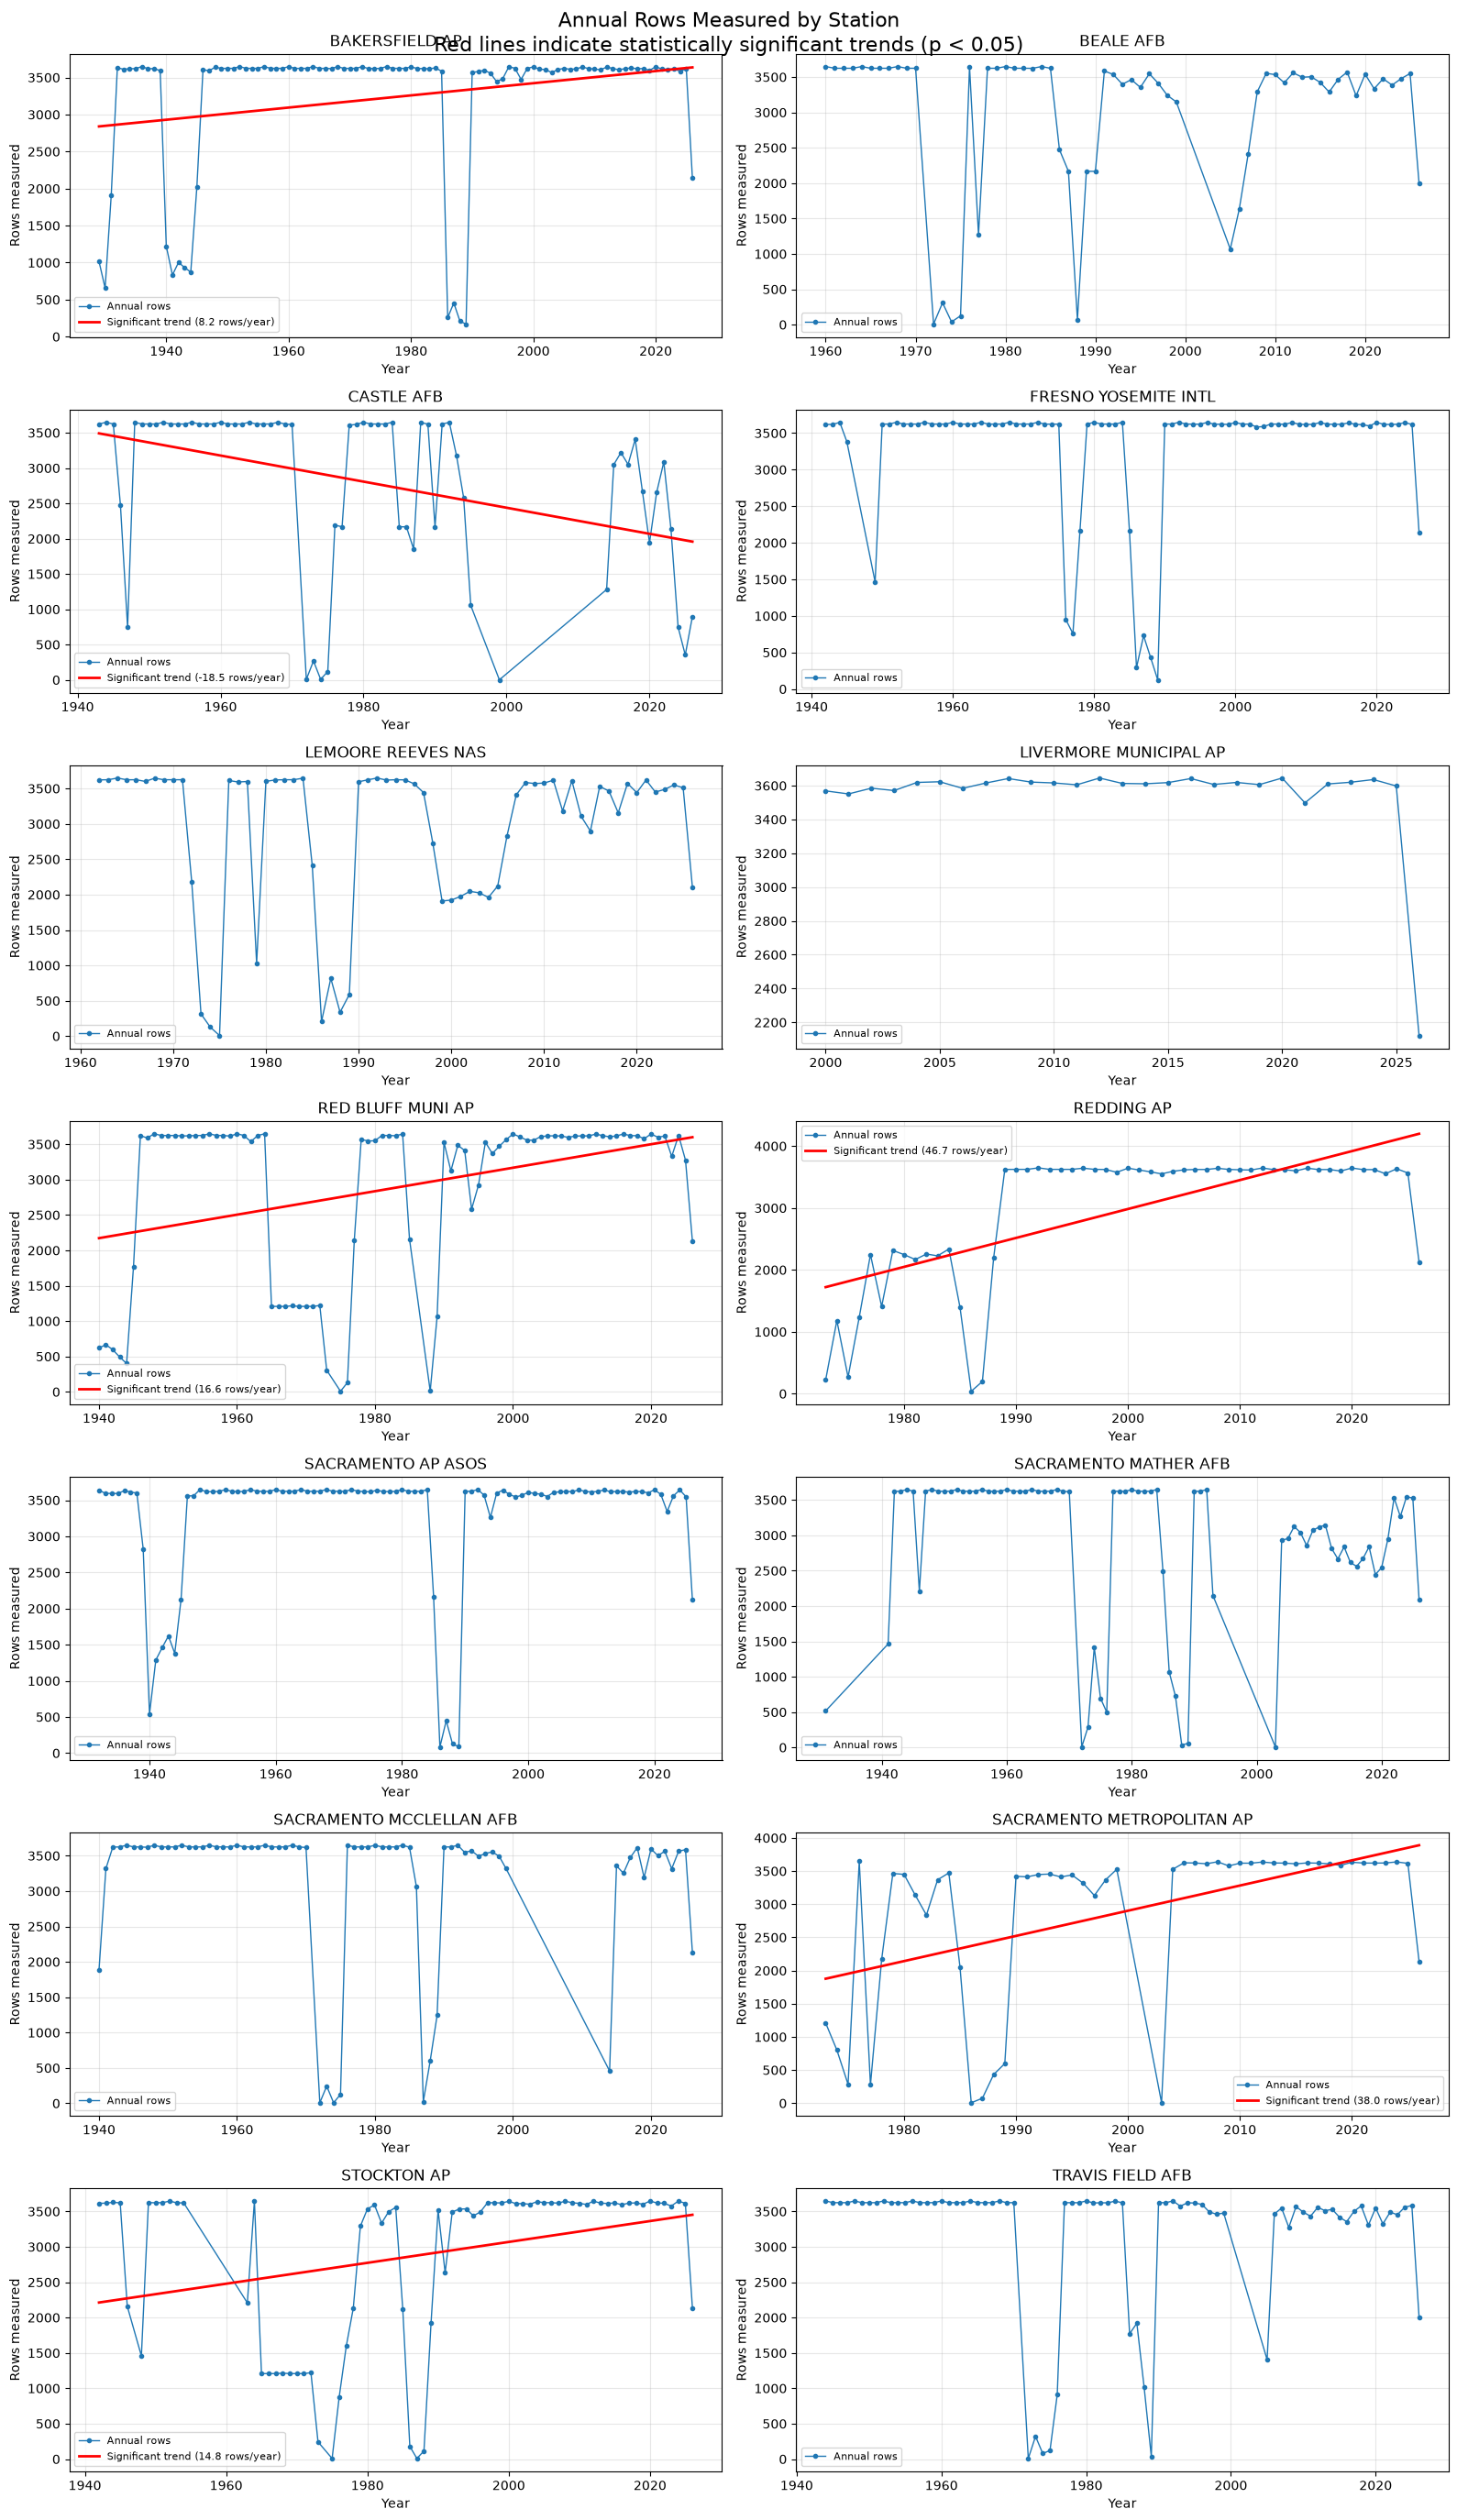

In [12]:
# Plot annual row counts separately for each station.
# Trend lines are shown only for statistically significant trends.

stations = sorted(yearly_row_counts["STATION"].unique())
ncols = 2
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 4 * nrows),
    squeeze=False
)

axes = axes.ravel()

for ax, station_name in zip(axes, stations):
    data = (
        yearly_row_counts[yearly_row_counts["STATION"] == station_name]
        .sort_values("year")
    )

    ax.plot(
        data["year"],
        data["row_count"],
        marker="o",
        markersize=3,
        linewidth=1,
        label="Annual rows"
    )

    trend_matches = trend_summary_rows[
        trend_summary_rows["STATION"] == station_name
    ]

    # Stations with fewer than three years have no calculated trend.
    trend_info = (
        trend_matches.iloc[0]
        if not trend_matches.empty
        else pd.Series({"significant": False})
    )

    if trend_info["significant"]:
        slope, intercept, _, _, _ = stats.linregress(
            data["year"],
            data["row_count"]
        )

        ax.plot(
            data["year"],
            intercept + slope * data["year"],
            color="red",
            linewidth=2,
            label=f"Significant trend ({slope:.1f} rows/year)"
        )

    ax.set_title(station_name)
    ax.set_xlabel("Year")
    ax.set_ylabel("Rows measured")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(stations):]:
    ax.remove()

fig.suptitle(
    "Annual Rows Measured by Station\n"
    "Red lines indicate statistically significant trends (p < 0.05)",
    fontsize=16
)

plt.tight_layout()
plt.show()

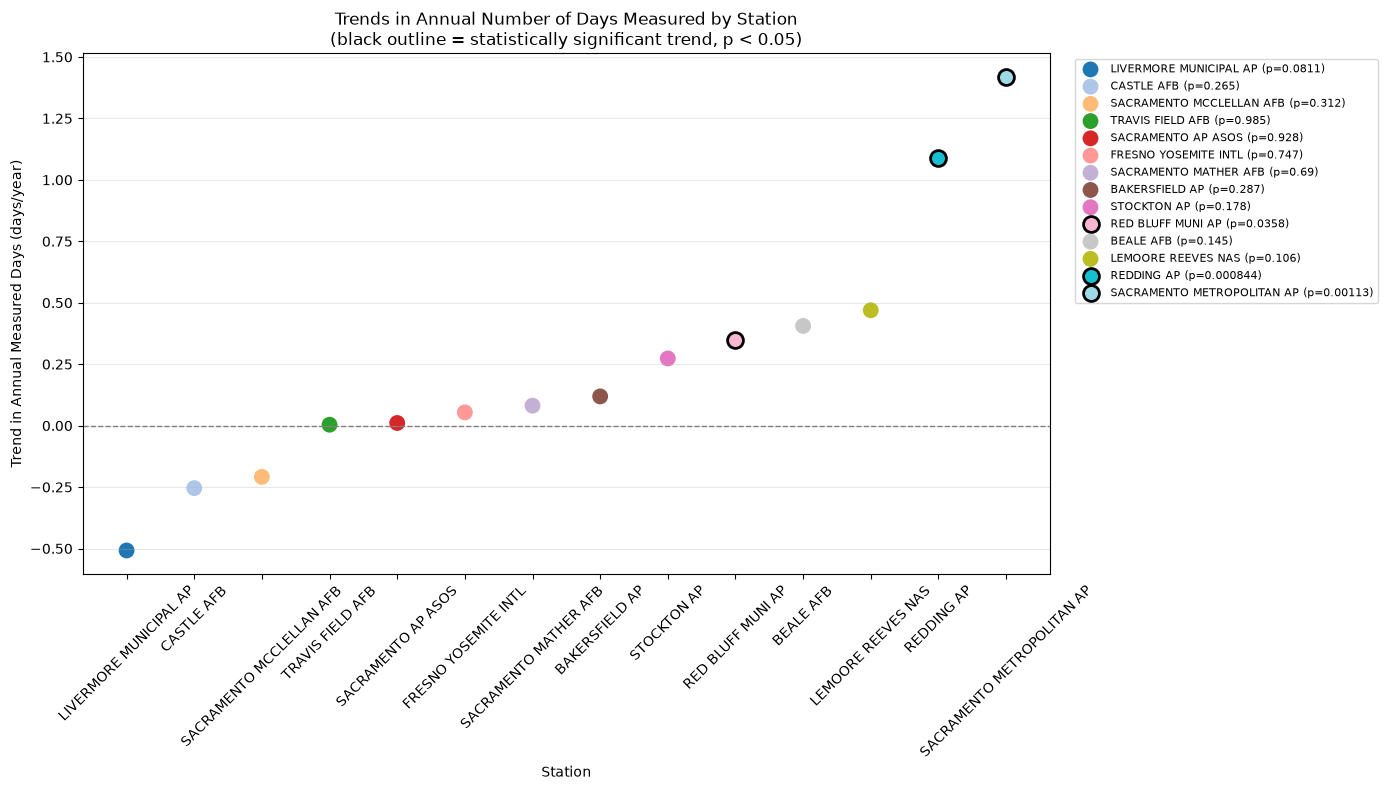

,STATION,slope_days_per_year,p_value,n_years,significant
5,LIVERMORE MUNICIPAL AP,-0.507937,0.081078,27,False
2,CASTLE AFB,-0.254270,0.265329,66,False
10,SACRAMENTO MCCLELLAN AFB,-0.208385,0.312100,72,False
13,TRAVIS FIELD AFB,0.003741,0.984789,77,False
8,SACRAMENTO AP ASOS,0.010750,0.927509,95,False
3,FRESNO YOSEMITE INTL,0.053836,0.747082,82,False
9,SACRAMENTO MATHER AFB,0.081320,0.689806,77,False
0,BAKERSFIELD AP,0.118891,0.286982,98,False
12,STOCKTON AP,0.273346,0.177509,75,False
6,RED BLUFF MUNI AP,0.347731,0.035831,84,True


In [13]:
# Annual number of unique measured days and trends by station

yearly_day_counts = (
    CV_rows[["STATION", "year", "month", "day"]]
    .drop_duplicates()
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="days_measured")
)

day_trend_records = []

for station, station_data in yearly_day_counts.groupby("STATION"):
    station_data = station_data.sort_values("year")

    if len(station_data) < 3:
        continue

    x_days = station_data["year"].to_numpy()
    y_days = station_data["days_measured"].to_numpy()

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        x_days, y_days
    )

    day_trend_records.append({
        "STATION": station,
        "slope_days_per_year": slope,
        "p_value": p_value,
        "n_years": len(station_data),
        "significant": p_value < 0.05,
    })

day_trend_summary = (
    pd.DataFrame(day_trend_records)
    .sort_values("slope_days_per_year")
)

# Plot one trend point per station
fig, ax = plt.subplots(figsize=(14, 8))

station_colors_days = plt.cm.tab20(
    np.linspace(0, 1, len(day_trend_summary))
)

for color, (_, row) in zip(
    station_colors_days, day_trend_summary.iterrows()
):
    ax.scatter(
        row["STATION"],
        row["slope_days_per_year"],
        s=130,
        color=color,
        edgecolors="black" if row["significant"] else "none",
        linewidths=2 if row["significant"] else 0,
        label=f'{row["STATION"]} (p={row["p_value"]:.3g})',
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Station")
ax.set_ylabel("Trend in Annual Measured Days (days/year)")
ax.set_title(
    "Trends in Annual Number of Days Measured by Station\n"
    "(black outline = statistically significant trend, p < 0.05)"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

display(day_trend_summary)

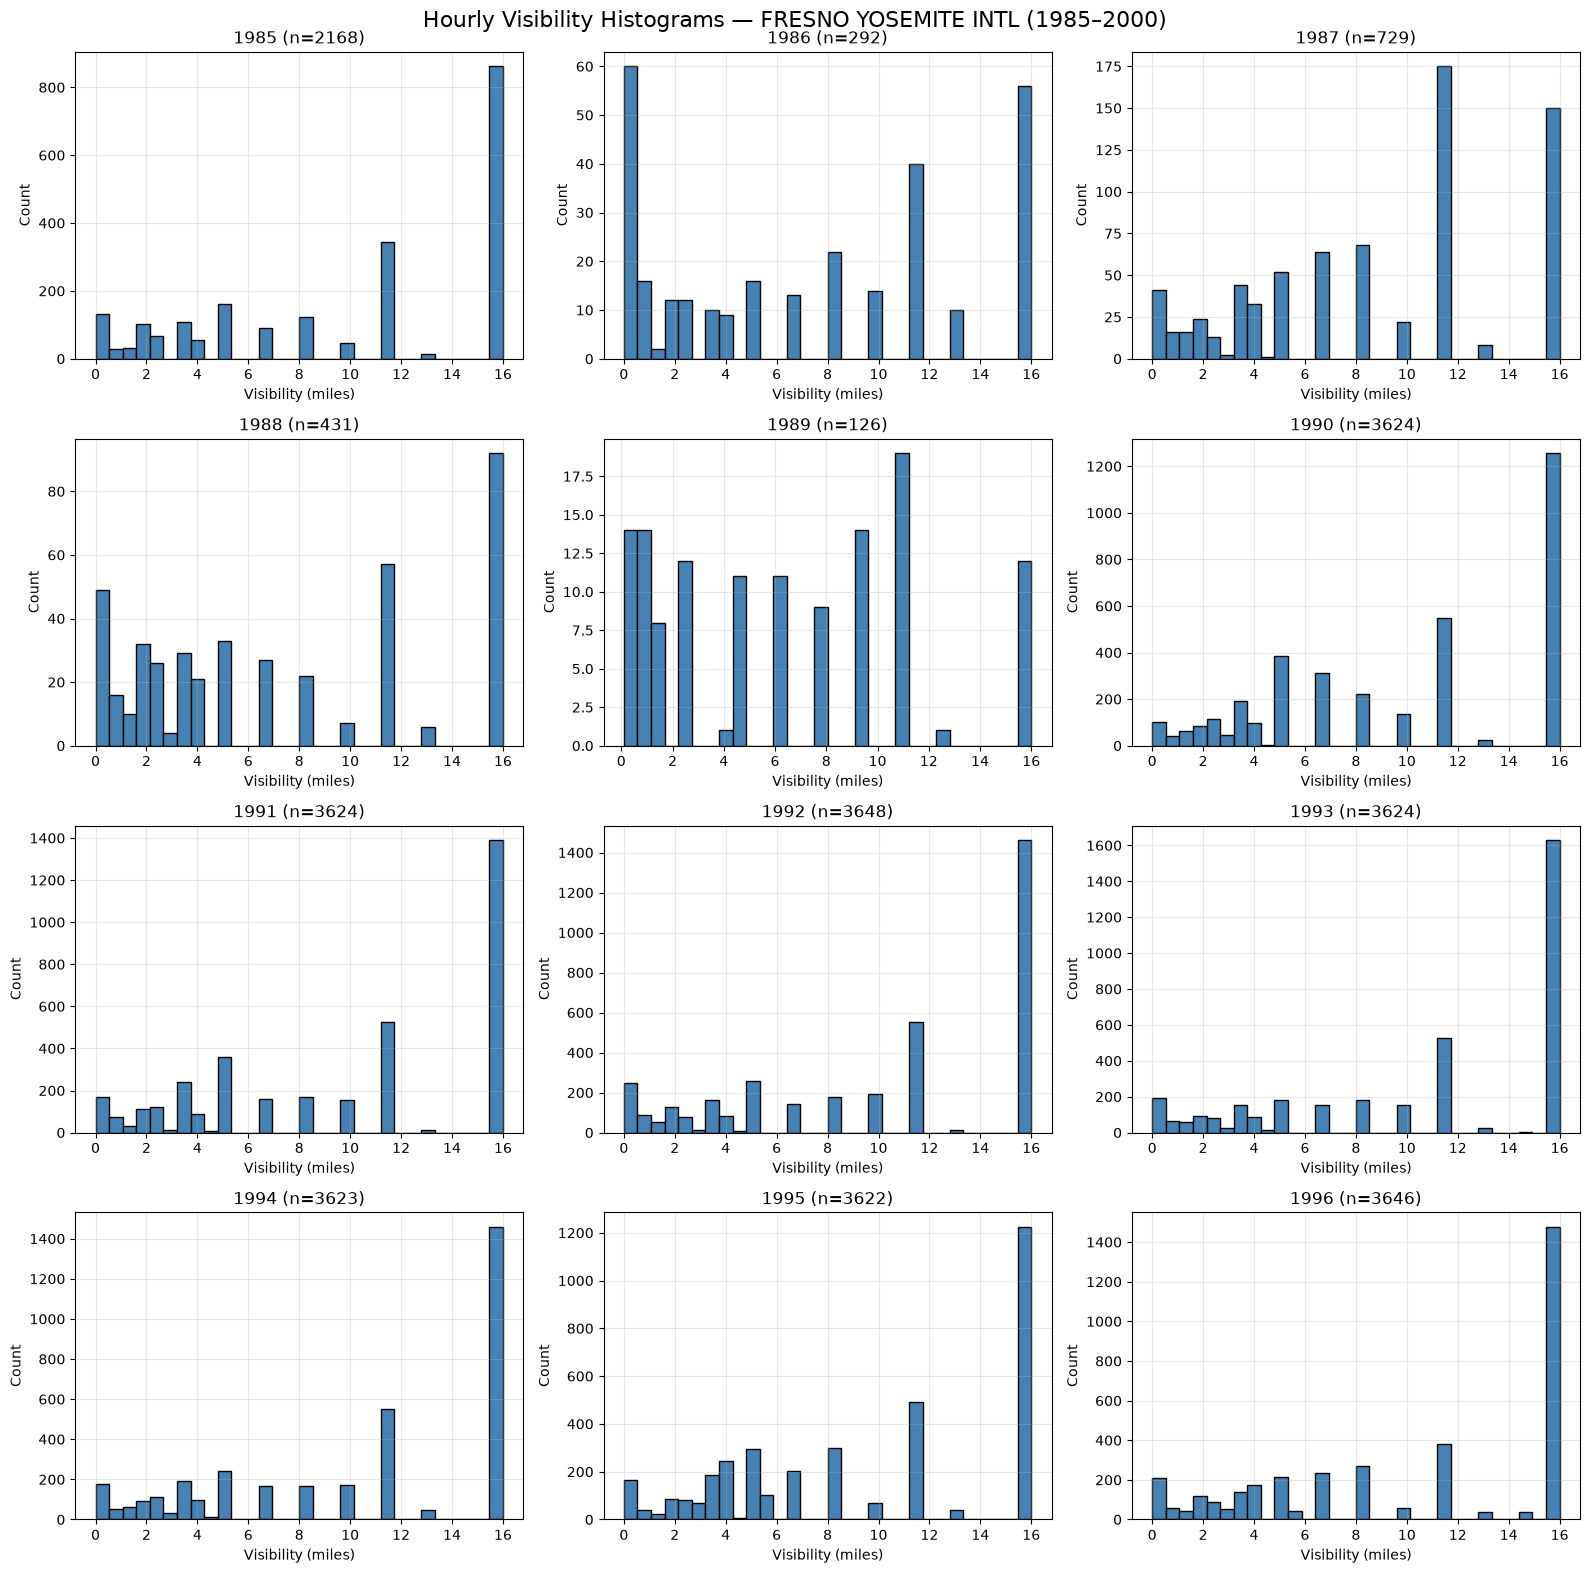

In [14]:
# Histogram of hourly visibility for FRESNO YOSEMITE INTL, years 1985-2000

station_name_vis = "FRESNO YOSEMITE INTL"
years_vis = list(range(1985, 2001))

# Subset the data for the specified station and years
subset_vis = CV_rows[
    # Filter by station and year
    (CV_rows["STATION"] == station_name_vis) &
    (CV_rows["year"].isin(years_vis))
].copy()

# Convert the HourlyVisibility column to numeric, coercing errors to NaN
subset_vis["HourlyVisibility"] = pd.to_numeric(
    subset_vis["HourlyVisibility"], errors="coerce"
)

# Set up the figure and axes for the histograms
fig, axes_vis = plt.subplots(4, 3, figsize=(16, 16), squeeze=False)
axes_vis = axes_vis.ravel()

# Loop through each year and plot the histogram for that year's visibility data
for ax, yr in zip(axes_vis, years_vis):
    # Get the visibility data for the current year
    yearly_vis = subset_vis.loc[subset_vis["year"] == yr, "HourlyVisibility"].dropna()

    # Plot the histogram for the current year's visibility data
    ax.hist(yearly_vis, bins=30, color="steelblue", edgecolor="black")
    # Set the title, labels, and grid for the current subplot
    ax.set_title(f"{yr} (n={len(yearly_vis)})")
    # Set the x-axis label for the current subplot
    ax.set_xlabel("Visibility (miles)")
    # Set the y-axis label for the current subplot
    ax.set_ylabel("Count")
    # Enable the grid for the current subplot
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Hourly Visibility Histograms — {station_name_vis} (1985–2000)", fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
# Total rows measured per year for FRESNO YOSEMITE INTL, 1983–1990

fresno_rows_1983_1990 = (
    CV_rows[
        (CV_rows["STATION"] == "FRESNO YOSEMITE INTL") &
        # (CV_rows["STATION"] == "BAKERSFIELD AP") &
        # (CV_rows["STATION"] == "SACRAMENTO AP ASOS") &
        (CV_rows["year"].between(1983, 1990))
    ]
    .groupby("year")
    .size()
    .reindex(range(1983, 1991), fill_value=0)
    .rename("total_rows_measured")
    .reset_index()
)

display(fresno_rows_1983_1990)

,year,total_rows_measured
0,1983,3624
1,1984,3648
2,1985,2168
3,1986,292
4,1987,729
5,1988,431
6,1989,126
7,1990,3624


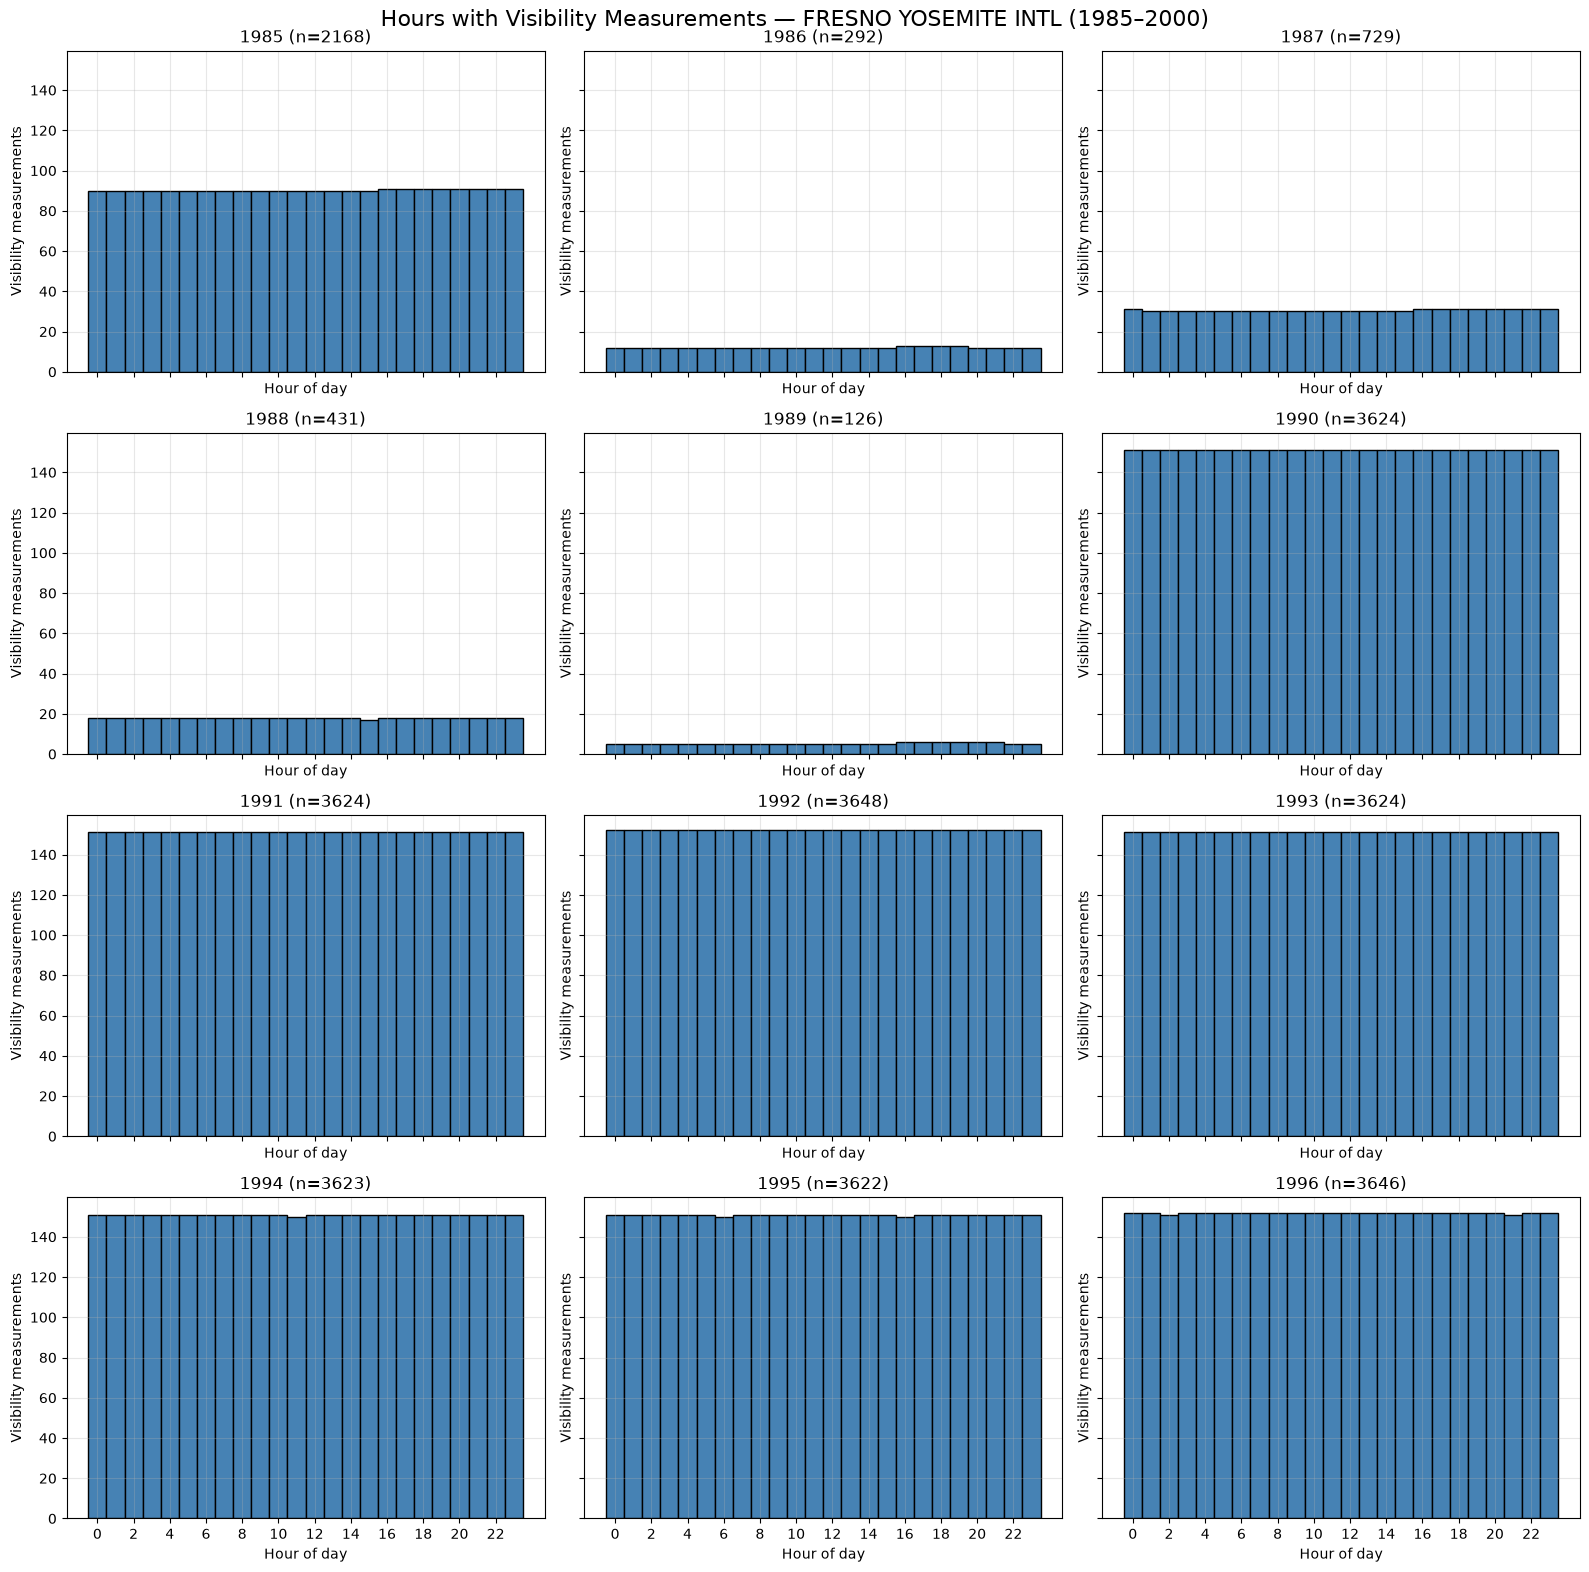

In [15]:
# Histogram of hours with visibility measurements by year

fig, axes_hours = plt.subplots(4, 3, figsize=(16, 16), sharex=True, sharey=True)
axes_hours = axes_hours.ravel()

hour_bins = np.arange(-0.5, 24.5, 1)

for ax, yr in zip(axes_hours, years_vis):
    year_data = subset_vis[
        (subset_vis["year"] == yr) &
        (subset_vis["HourlyVisibility"].notna())
    ]

    ax.hist(
        year_data["hour"],
        bins=hour_bins,
        color="steelblue",
        edgecolor="black"
    )
    ax.set_title(f"{yr} (n={len(year_data)})")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Visibility measurements")
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Hours with Visibility Measurements — FRESNO YOSEMITE INTL (1985–2000)",
    fontsize=16
)
plt.tight_layout()
plt.show()

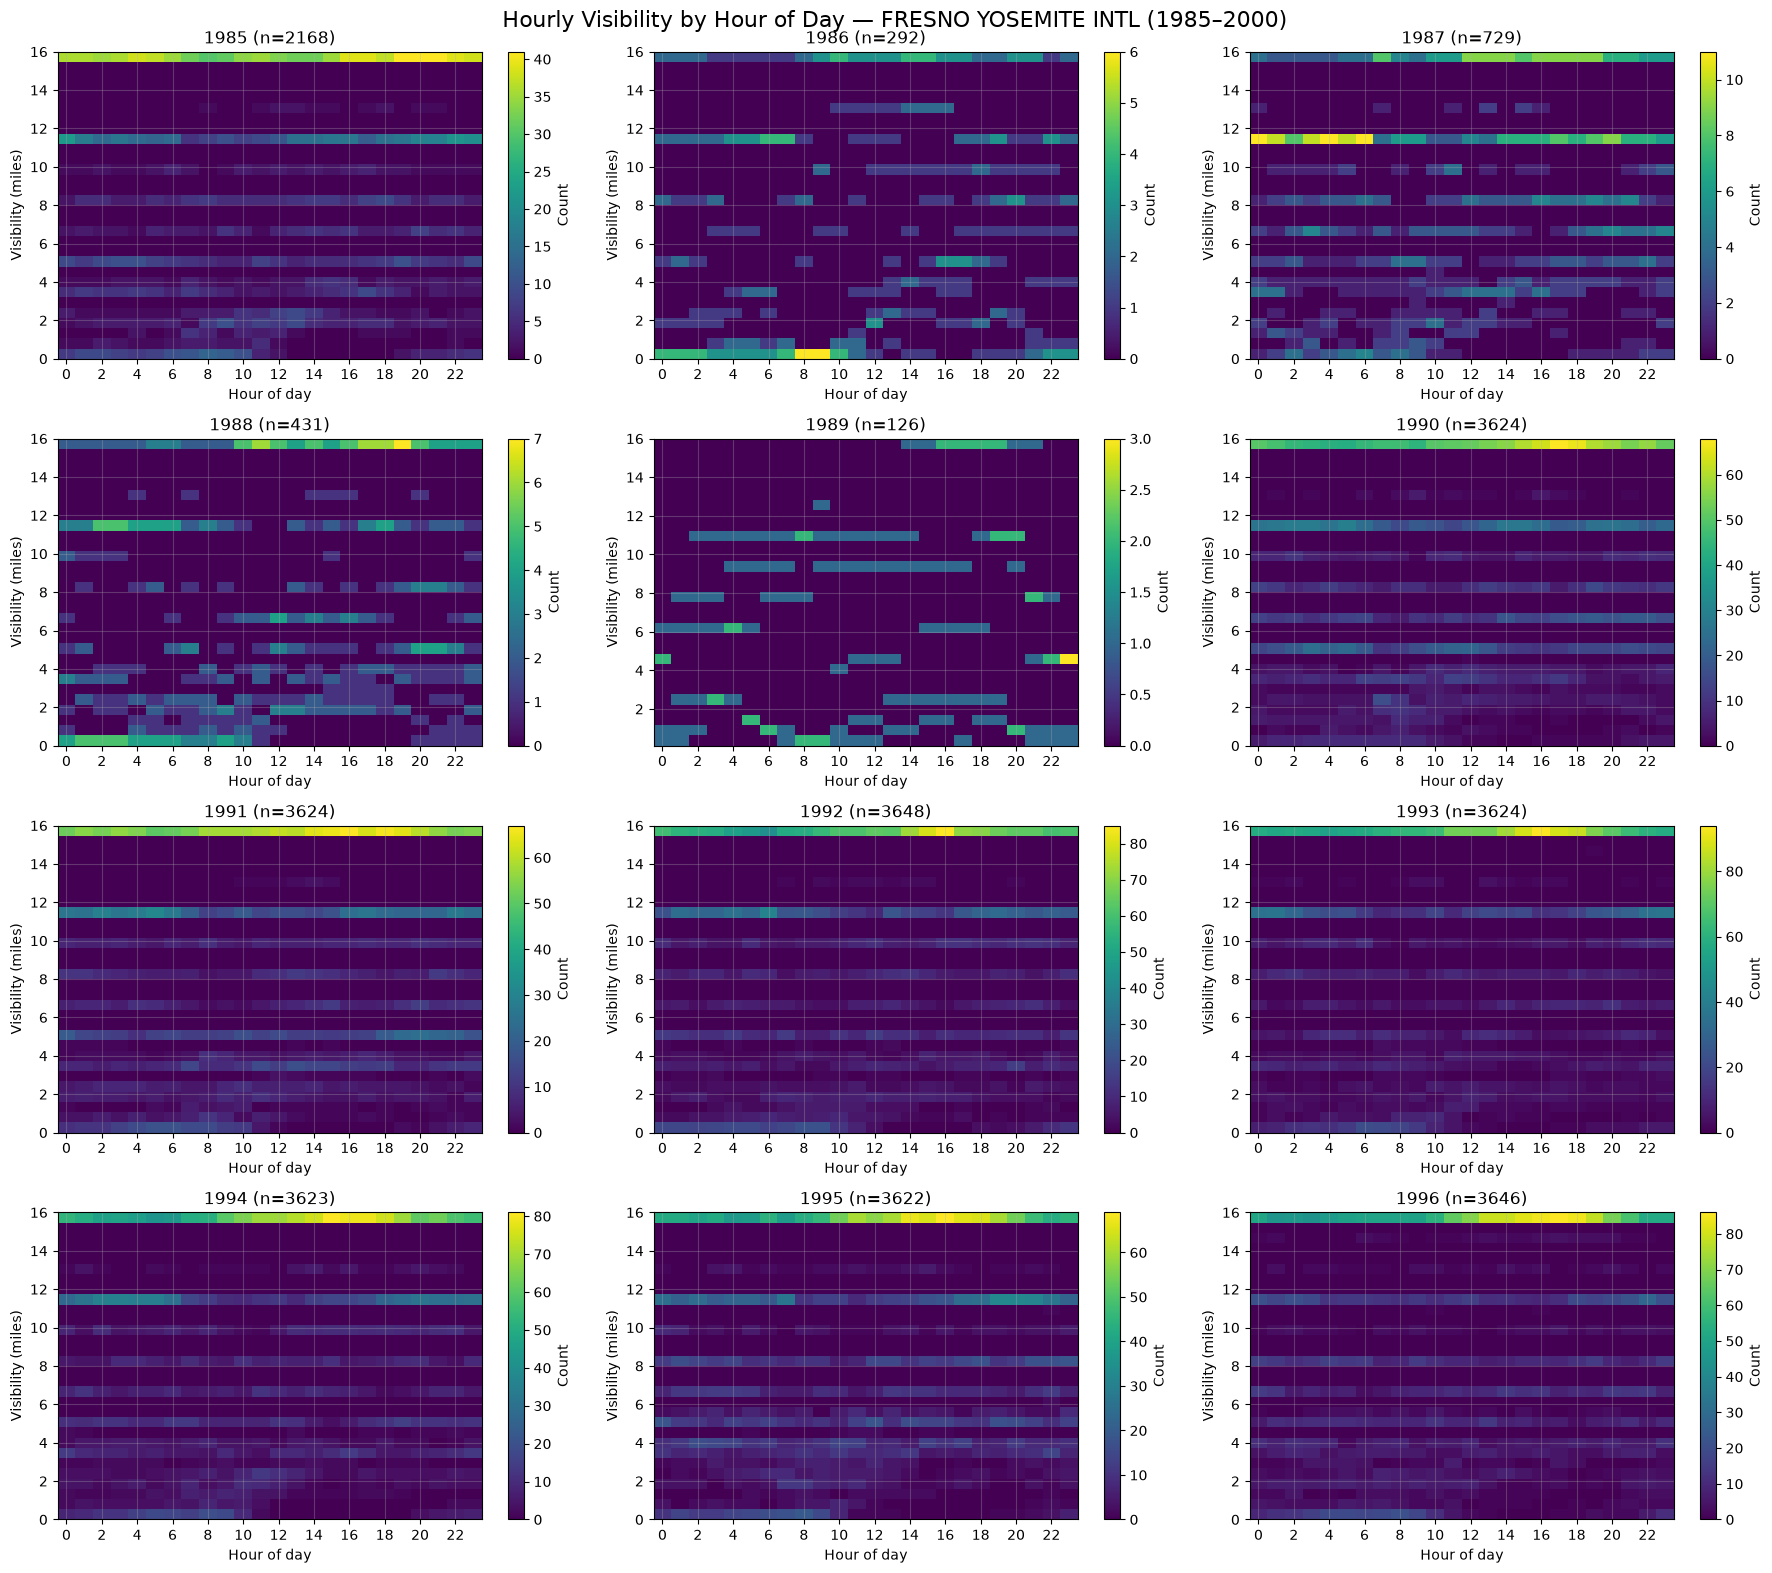

In [16]:
# Histogram of hourly visibility by hour of day, for FRESNO YOSEMITE INTL, years 1985-2000
# Plot Number of measurements by hour of the day

fig, axes_vis_hour = plt.subplots(4, 3, figsize=(18, 16), squeeze=False)
axes_vis_hour = axes_vis_hour.ravel()

for ax, yr in zip(axes_vis_hour, years_vis):
    year_data_vis = subset_vis[
        (subset_vis["year"] == yr) &
        (subset_vis["HourlyVisibility"].notna())       
    ]

    h2d = ax.hist2d(
        # x-axis: hour of the day
        year_data_vis["hour"],
        # y-axis: count of measurements taken
        year_data_vis["HourlyVisibility"],
        bins=[hour_bins, 30],
        cmap="viridis"
    )
    fig.colorbar(h2d[3], ax=ax, label="Count")

    ax.set_title(f"{yr} (n={len(year_data_vis)})")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Visibility (miles)")
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Hourly Visibility by Hour of Day — FRESNO YOSEMITE INTL (1985–2000)",
    fontsize=16
)
plt.tight_layout()
plt.show()

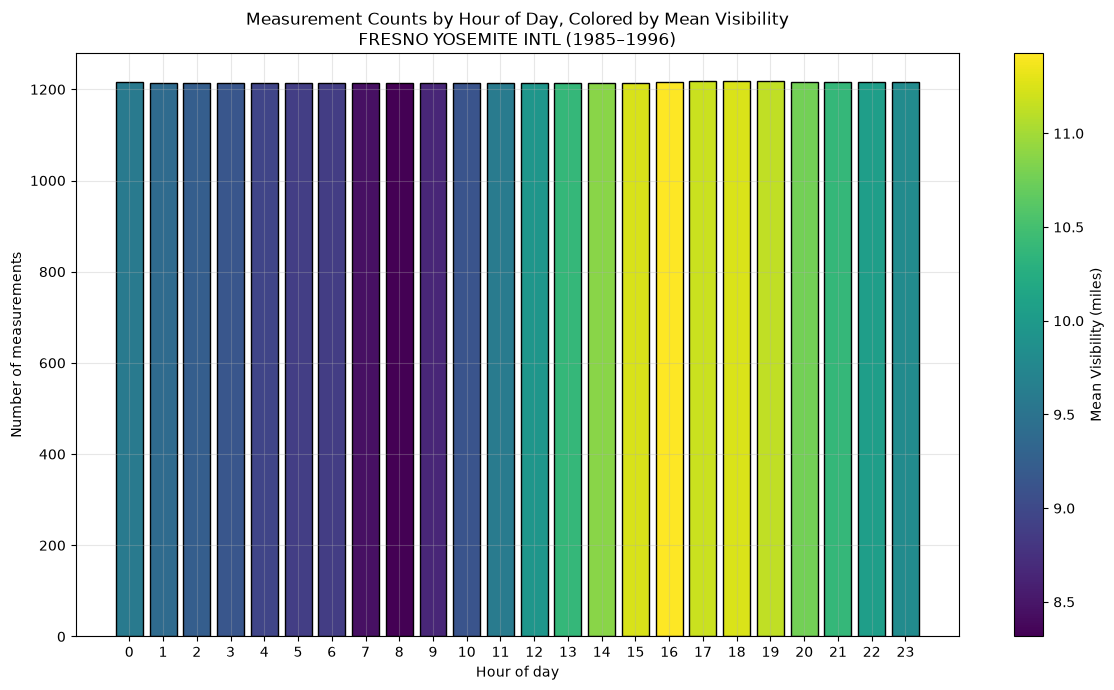

In [17]:
# Colormap histogram: hour of day vs count of measurements, colored by mean visibility
# for FRESNO YOSEMITE INTL, years 1985-1996

years_range_1985_1996 = list(range(1985, 1997))

subset_range = subset_vis[subset_vis["year"].isin(years_range_1985_1996)].copy()

fig, ax_hourly_vis = plt.subplots(figsize=(12, 7))

# Compute mean visibility per hour bin
hourly_stats = (
    subset_range.groupby("hour")["HourlyVisibility"]
    .agg(["count", "mean"])
    .reindex(range(24), fill_value=0)
)

bars = ax_hourly_vis.bar(
    hourly_stats.index,
    hourly_stats["count"],
    color=plt.cm.viridis(
        (hourly_stats["mean"] - hourly_stats["mean"].min()) /
        (hourly_stats["mean"].max() - hourly_stats["mean"].min())
    ),
    edgecolor="black"
)

sm_cbar = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(vmin=hourly_stats["mean"].min(), vmax=hourly_stats["mean"].max())
)
sm_cbar.set_array([])
cbar = fig.colorbar(sm_cbar, ax=ax_hourly_vis)
cbar.set_label("Mean Visibility (miles)")

ax_hourly_vis.set_xlabel("Hour of day")
ax_hourly_vis.set_ylabel("Number of measurements")
ax_hourly_vis.set_xticks(range(0, 24))
ax_hourly_vis.set_title(
    "Measurement Counts by Hour of Day, Colored by Mean Visibility\n"
    "FRESNO YOSEMITE INTL (1985–1996)"
)
ax_hourly_vis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_6308\2266381772.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


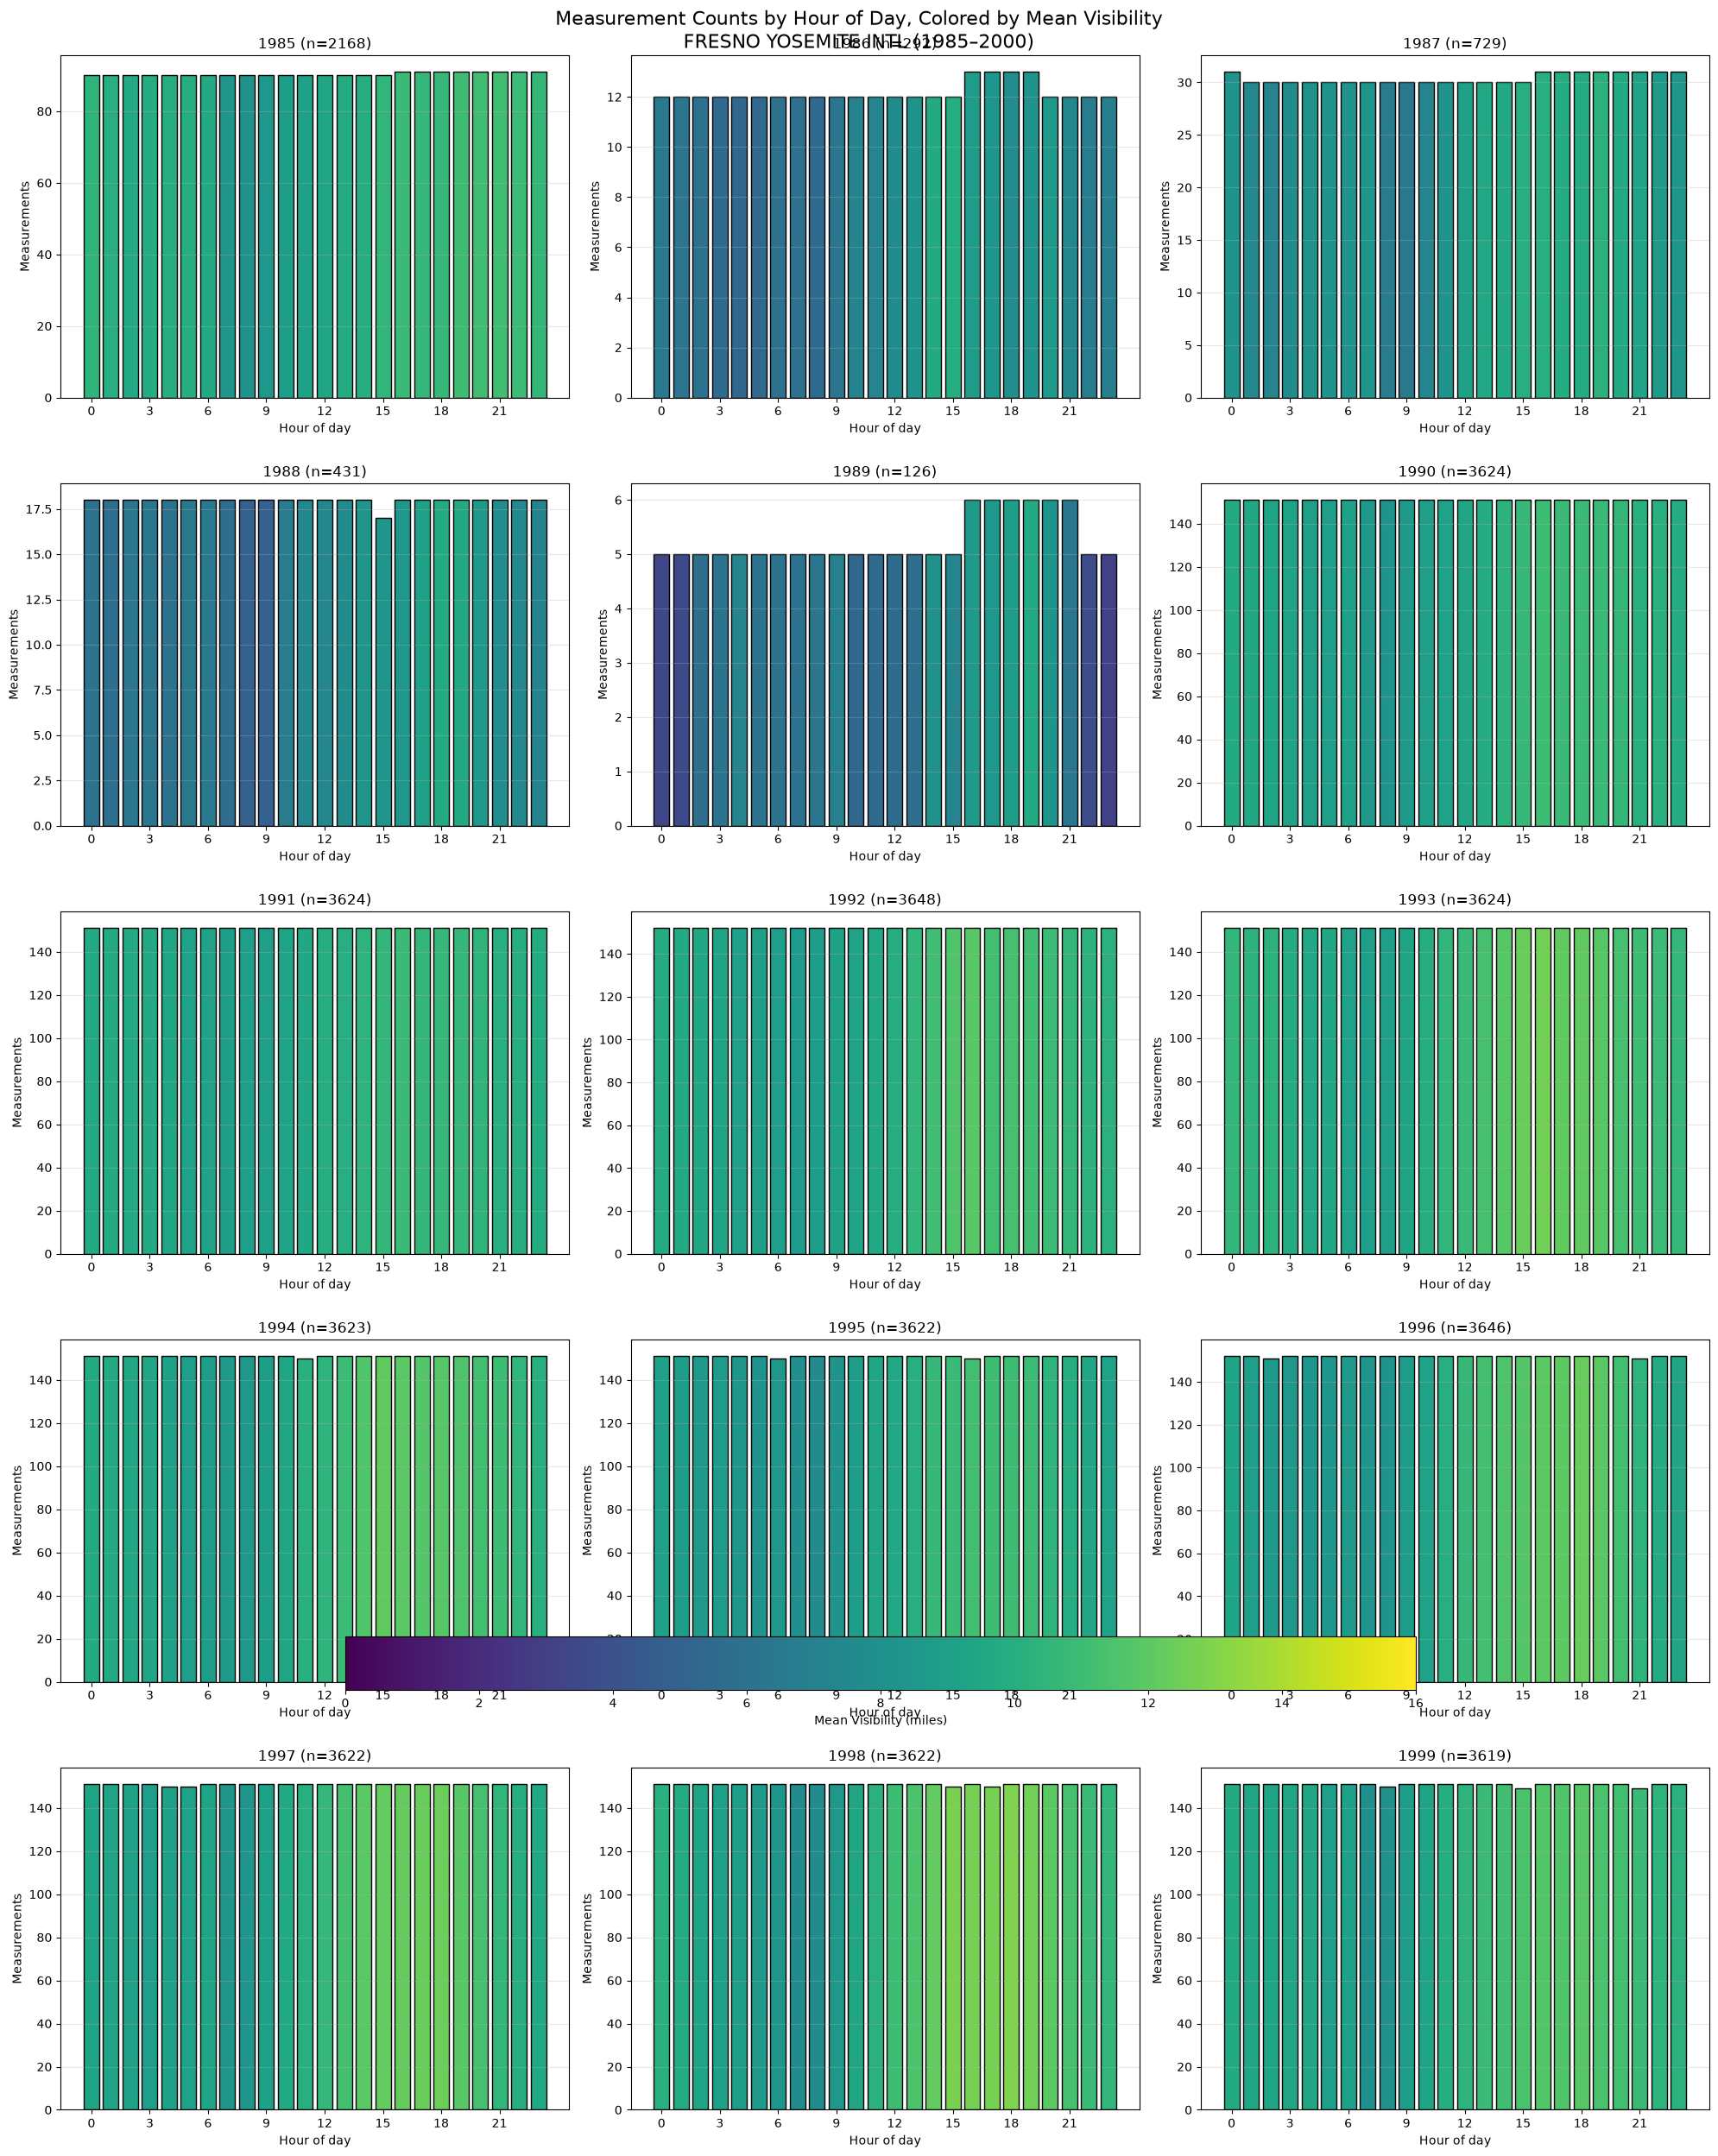

In [18]:
# Measurement counts by hour, colored by mean visibility for each year

fig, axes_yearly = plt.subplots(
    5, 3, figsize=(20, 25), sharey=False, squeeze=False
)
axes_yearly = axes_yearly.ravel()

visibility_norm = plt.Normalize(
    vmin=subset_vis["HourlyVisibility"].min(),
    vmax=subset_vis["HourlyVisibility"].max()
)
visibility_cmap = plt.cm.viridis

for ax, year_value in zip(axes_yearly, years_vis):
    year_subset = subset_vis[subset_vis["year"] == year_value]

    hourly_year_stats = (
        year_subset.groupby("hour")["HourlyVisibility"]
        .agg(count="count", mean="mean")
        .reindex(range(24))
    )

    colors_year = visibility_cmap(
        visibility_norm(hourly_year_stats["mean"].fillna(0))
    )

    ax.bar(
        hourly_year_stats.index,
        hourly_year_stats["count"].fillna(0),
        color=colors_year,
        edgecolor="black"
    )

    ax.set_title(f"{year_value} (n={len(year_subset)})")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Measurements")
    ax.set_xticks(range(0, 24, 3))
    ax.grid(True, axis="y", alpha=0.3)

sm_yearly = plt.cm.ScalarMappable(
    cmap=visibility_cmap,
    norm=visibility_norm
)
sm_yearly.set_array([])

fig.colorbar(
    sm_yearly,
    ax=axes_yearly.tolist(),
    label="Mean Visibility (miles)",
    shrink=0.8,
    # put the colorbar beneath the subplots
    orientation="horizontal",
    # put the colorbar in the bottom of the image
    location="bottom"
)

fig.suptitle(
    "Measurement Counts by Hour of Day, Colored by Mean Visibility\n"
    f"{station_name_vis} ({years_vis[0]}–{years_vis[-1]})",
    fontsize=16
)

plt.tight_layout()
plt.show()